#**LOAD DATASET**

In [2]:
import pandas as pd

file_path = 'C:/Users/Dark Lord/Downloads/jupyter/Pem/audit_risk_dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,Transaction_ID,Transaction_Amount,Transaction_Type,Vendor_Risk_Score,Employee_ID,Department,Transaction_Frequency,Round_Amount_Flag,Weekend_Transaction,Approval_Level,Previous_Fraud_Flag,Unusual_Time_Flag,Multiple_Approvals,Vendor_New_Flag,Audit_Risk
0,T00001,9385.36,Expense,0.75,E394,Finance,28,1,0,VP,0,0,1,0,0
1,T00002,60202.43,Transfer,0.15,E395,Admin,25,0,0,Manager,0,0,0,0,0
2,T00003,26334.91,Purchase,0.87,E234,Finance,17,0,1,VP,0,0,0,1,0
3,T00004,18258.85,Transfer,0.64,E132,Finance,8,0,0,VP,0,0,1,0,0
4,T00005,3392.50,Expense,0.23,E392,Admin,6,0,0,Manager,0,0,0,0,0


#**QUICK OVERVIEW**

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         10000 non-null  object 
 1   Transaction_Amount     10000 non-null  float64
 2   Transaction_Type       10000 non-null  object 
 3   Vendor_Risk_Score      10000 non-null  float64
 4   Employee_ID            10000 non-null  object 
 5   Department             10000 non-null  object 
 6   Transaction_Frequency  10000 non-null  int64  
 7   Round_Amount_Flag      10000 non-null  int64  
 8   Weekend_Transaction    10000 non-null  int64  
 9   Approval_Level         10000 non-null  object 
 10  Previous_Fraud_Flag    10000 non-null  int64  
 11  Unusual_Time_Flag      10000 non-null  int64  
 12  Multiple_Approvals     10000 non-null  int64  
 13  Vendor_New_Flag        10000 non-null  int64  
 14  Audit_Risk             10000 non-null  int64  
dtypes: 

Transaction_ID           0
Transaction_Amount       0
Transaction_Type         0
Vendor_Risk_Score        0
Employee_ID              0
Department               0
Transaction_Frequency    0
Round_Amount_Flag        0
Weekend_Transaction      0
Approval_Level           0
Previous_Fraud_Flag      0
Unusual_Time_Flag        0
Multiple_Approvals       0
Vendor_New_Flag          0
Audit_Risk               0
dtype: int64

#**EDA**

1. Target Distribution

<Axes: xlabel='Audit_Risk', ylabel='count'>

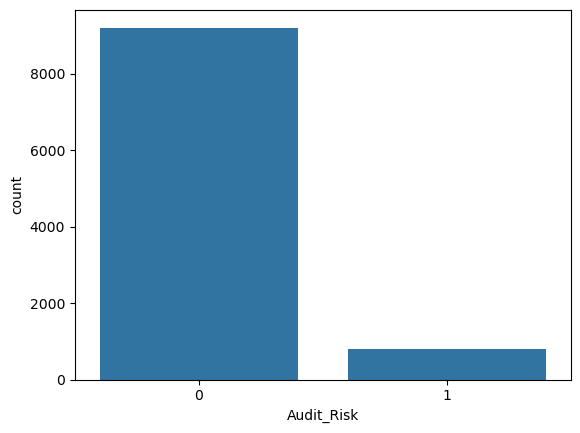

In [4]:
import seaborn as sns
sns.countplot(x="Audit_Risk", data=df)

2. Transaction Amount vs Risk

<Axes: xlabel='Audit_Risk', ylabel='Transaction_Amount'>

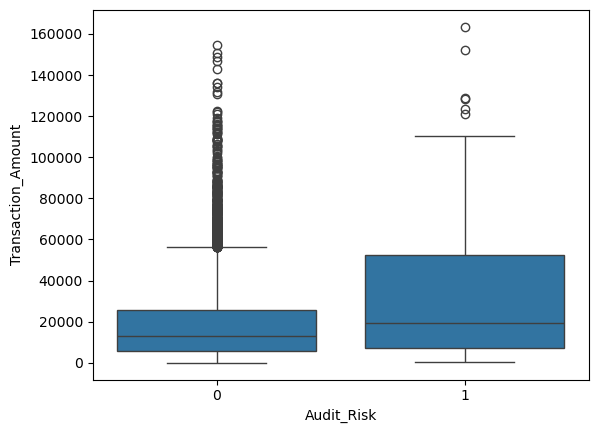

In [5]:
sns.boxplot(x="Audit_Risk", y="Transaction_Amount", data=df)

3. Vendor Risk Score

<Axes: xlabel='Audit_Risk', ylabel='Vendor_Risk_Score'>

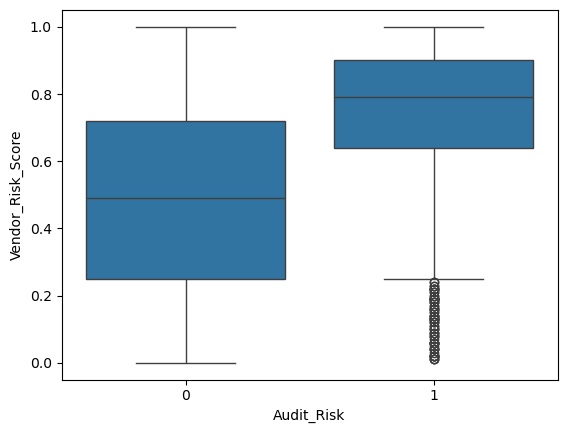

In [6]:
sns.boxplot(x="Audit_Risk", y="Vendor_Risk_Score", data=df)

4. Previous Fraud Flag

<Axes: xlabel='Previous_Fraud_Flag', ylabel='count'>

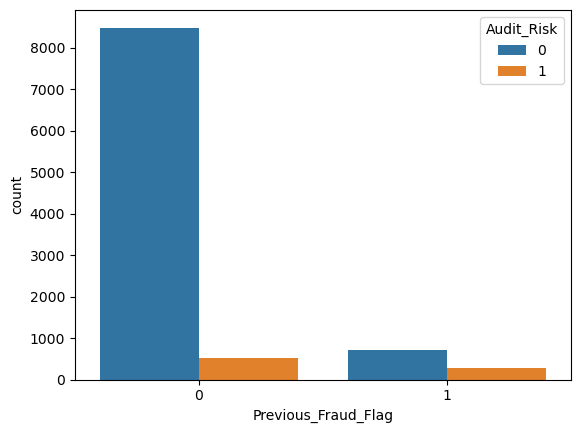

In [7]:
sns.countplot(x="Previous_Fraud_Flag", hue="Audit_Risk", data=df)

5. Weekend / Unusual Transactions

<Axes: xlabel='Weekend_Transaction', ylabel='count'>

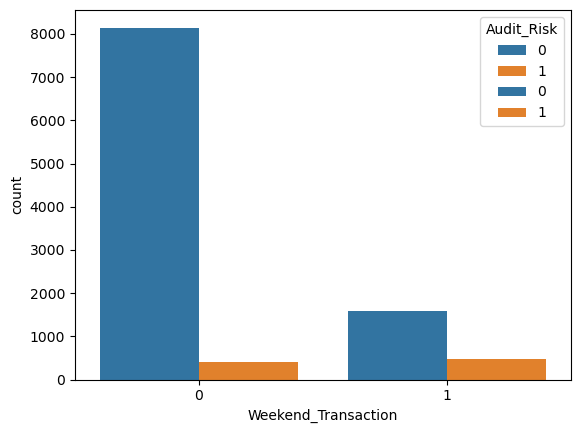

In [8]:
sns.countplot(x="Weekend_Transaction", hue="Audit_Risk", data=df)
sns.countplot(x="Unusual_Time_Flag", hue="Audit_Risk", data=df)

6. Correlation Heatmap

<Axes: >

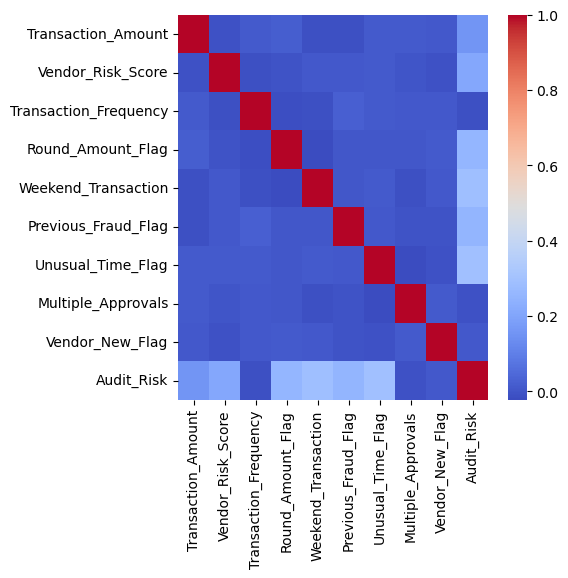

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

#**DATA PREPARATION**

Encoding Categorical Columns

In [10]:
df = pd.get_dummies(df, drop_first=True)

Define Features

In [11]:
X = df.drop("Audit_Risk", axis=1)
y = df["Audit_Risk"]

Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

#**MODEL BUILDING**

Model 1: Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=900, random_state=42)
lr.fit(X_train, y_train)

c:\Users\Dark Lord\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 900 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=900).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,900
,multi_class,'deprecated'


Model 2: Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#**EVALUATION**

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2288    0]
 [ 175   37]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      2288
           1       1.00      0.17      0.30       212

    accuracy                           0.93      2500
   macro avg       0.96      0.59      0.63      2500
weighted avg       0.93      0.93      0.91      2500



In [21]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate Logistic Regression model
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Model Evaluation:")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")

# Evaluate Random Forest model
y_pred_rf = rf.predict(X_test)
print("Random Forest Model Evaluation:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")



Logistic Regression Model Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2288
           1       0.53      0.64      0.58       212

    accuracy                           0.92      2500
   macro avg       0.75      0.79      0.77      2500
weighted avg       0.93      0.92      0.92      2500

Accuracy: 0.9208

Random Forest Model Evaluation:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      2288
           1       1.00      0.17      0.30       212

    accuracy                           0.93      2500
   macro avg       0.96      0.59      0.63      2500
weighted avg       0.93      0.93      0.91      2500

Accuracy: 0.9300


In [23]:
%pip install xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=10)
xgb.fit(X_train, y_train)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 7.2 MB/s eta 0:00:14
    --------------------------------------- 1.6/101.7 MB 4.7 MB/s eta 0:00:22
    --------------------------------------- 2.4/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.1/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 4.7/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 5.5/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.3/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.1/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.6/101.7 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 8.7/101.7 MB 3.9 MB/s eta 0:00:24
   --- ------------------------------------ 9.4/101.7 MB 3.9 MB/s eta 0

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
# Evaluate XGBoost model
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Model Evaluation:")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      2288
           1       0.52      0.95      0.67       212

    accuracy                           0.92      2500
   macro avg       0.76      0.93      0.81      2500
weighted avg       0.95      0.92      0.93      2500

Accuracy: 0.9200


#**FEATURE IMPORTANCE**

<Axes: >

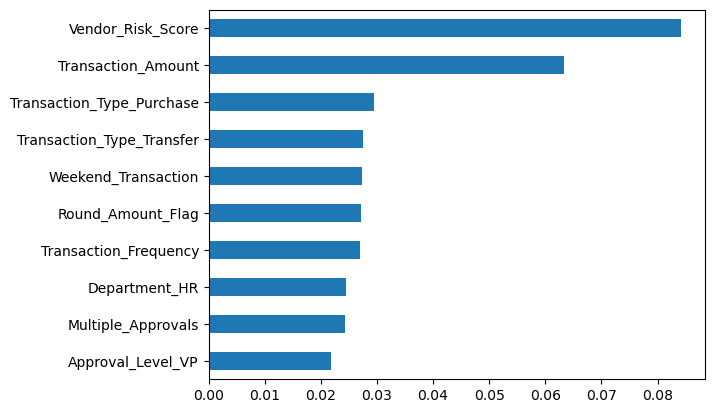

In [25]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')

#**RISK SCORING SYSTEM**

In [29]:
risk_score = xgb.predict_proba(X_test)[:, 1]

Categorize Risk

In [30]:
def risk_category(score):
    if score < 0.3:
        return "Low Risk"
    elif score < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

In [31]:
import joblib

joblib.dump(xgb, "xgb_audit_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [ ]:

import streamlit as st
import joblib   
model = joblib.load("xgb_audit_model.pkl")
model_columns = joblib.load("model_columns.pkl")
